# Data Science in Earth Observation - Classification

## Agenda

### Part 1
1. [Introduction](#1.-Introduction)
2. [Meet the Data](#2.-Meet-the-Data)
3. [Machine Learning: Random Forest Classifier](#3.-Machine-Learning:-Random-Forest-Classifier)
4. [Other ML Models](#4.-Other-ML-Models)
5. [Deep Learning](#5.-Deep-Learning)
6. [DL Preprocessing](#6.-DL-Preprocessing)
7. [Residual Networks](#7.-Residual-Networks)

## 1. Introduction: So2Sat LCZ42

By 2050, Berlin summers could be as hot as in Canberra, Australia. Pankow, a district in the city’s north, has already declared a climate emergency in 2019 and is planning ahead. It is planting trees from the Mediterranean that can withstand the heat, and has calculated computer simulations for sunshine and cold air corridors for the construction of 1200 new apartments. A few changes, like swapping asphalt and concrete that store heat against greenery that soaks up water and provides shade, can make a difference on the local scale. Many of these changes on a local scale then make a difference on the bigger scale.

To understand local climate in cities, scientists have developed the Local Climate Zone classification scheme, as part of the So2Sat project. The aim is to create a 4D urban map of the world.

It differentiates between 17 zones based mainly on surface structures (such as building and tree density) as well as surface cover (green, pervious soils versus impervious gray surfaces). There are algorithms that calculate these maps from freely available satellite imagery, but there’s still room for improvement by adapting or developing suitable and advanced Convolutional Neural Network (CNN) architectures that generalize well.

The outcome of So2Sat will be the first and unique global and consistent spatial data set on urban morphology (3D/4D) of settlements, and a multidisciplinary application derivate assessing population density. This is seen as a giant leap for urban geography research, as well as for formation of opinions for stakeholders based on resilient data.

![Data set](so2sat_dataset.png)


... and this is the data set paper:
```
@article{zhu2020so2sat,
  title={So2Sat LCZ42: a benchmark data set for the classification of global local climate zones [Software and Data Sets]},
  author={Zhu, Xiao Xiang and Hu, Jingliang and Qiu, Chunping and Shi, Yilei and Kang, Jian and Mou, Lichao and Bagheri, Hossein and Haberle, Matthias and Hua, Yuansheng and Huang, Rong and others},
  journal={IEEE Geoscience and Remote Sensing Magazine},
  volume={8},
  number={3},
  pages={76--89},
  year={2020},
  publisher={IEEE}
}
```

## 2. Meet the Data

The *So2Sat LCZ42* data set is an *Earth observation* image classification data set. It contains co-registered image patches from Sentinel-1 (10 multi-spectral bands) and Sentinel-2 (8 bands) satellite sensors, all assigned to one of the 17 *local climate zones* (LCZ) classes.

The LCZ classes are as follows: 
1) compact high-rise, 
2) compact mid-rise, 
3) compact low-rise,
4) open high-rise,
5) open mid-rise,
6) open low-rise,
7) lightweight low-rise,
8) large low-rise,
9) sparsely built, 
10) heavy industry,
11) dense trees,
12) scattered tree, 
13) bush, scrub,
14) low plants,
15) bare rock or paved,
16) bare soil or sand, and 
17) water

The data set is split into training (352,366 images), validation (24,188) and test (24,119).

It is important to note that two various pools of cities were used to build So2Sat LCZ42. 32 cities around the globe were selected to form the training set, while samples from 10 different cites were used for the validation and test set, with a geographical split (east and west).

![Sample](so2sat_sample.png)

In [ ]:
# Uncomment the following lines to install the required packages
# import sys
# !{sys.executable} -m pip install -r requirements.txt

Load the required packages

In [1]:
import h5py
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import colormaps

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf

I0000 00:00:1778175054.424267   35799 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778175054.466747   35799 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778175055.504791   35799 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# this should match the name of the downloaded data set
filename = 'data/subset_lcz42.h5'

dataset = h5py.File(filename, 'r')

# show the content names
print(list(dataset.keys()))

['label', 'sen1', 'sen2']


In [37]:
with h5py.File('data/subset_lcz42.h5', 'r') as f:
    # Let's assume your keys are 'sen2' (images) and 'label' (classes)
    # Get all rows from the dataset
    X = f['sen2'][:] 
    y = f['label'][:]

print(f"Loaded {X.shape[0]} rows.")

Loaded 2400 rows.


### Labels

In [3]:
# load the labels
labels = np.array(dataset['label'])

# show the shape
print("Labels shape: " + str(labels.shape))

# print the labels
print(labels[0:10,:])

Labels shape: (2400, 17)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


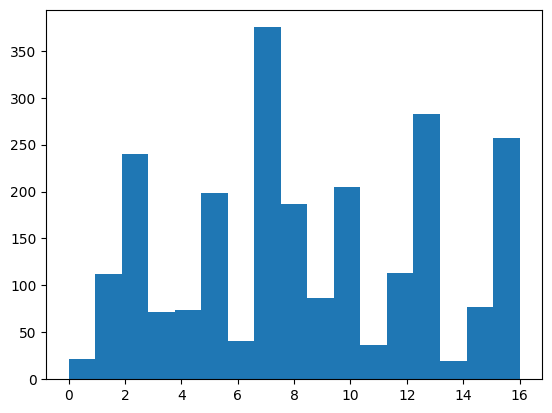

In [4]:
# Check the data distribution
plt.hist(np.argmax(labels, axis=1), bins=17)

# let's get a sample from each class
class_sample = np.argmax(labels, axis=0)
# print(class_sample)

### Sentinel-1

The data set contains the following channels:
1) the real part of the unfiltered VH channel
2) the imaginary part of the unfiltered VH channel
3) the real part of the unfiltered VV channel
4) the imaginary part of the unfiltered VV channel
5) the intensity of the refined Lee filtered VH channel
6) the intensity of the refined Lee filtered VV channel
7) the real part of the refined Lee filtered covariance matrix off-diagonal element
8) the imaginary part of the refined Lee filtered covariance matrix off-diagonal element

Sentinel-1 shape: (2400, 32, 32, 8)


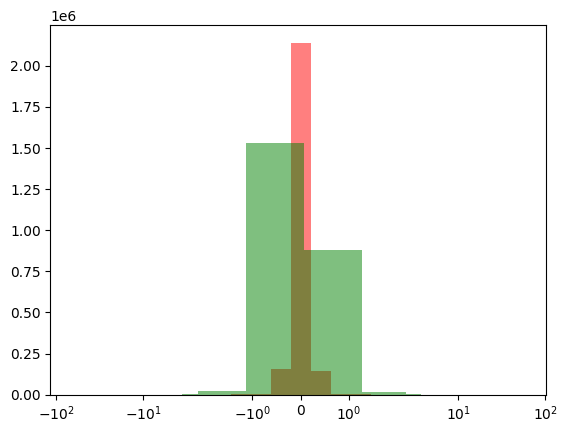

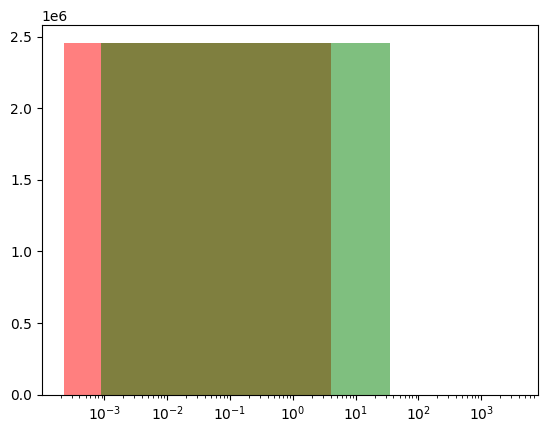

In [5]:
# load Sentinel-1 data
sen1 = np.array(dataset['sen1'])

print("Sentinel-1 shape: " + str(sen1.shape))

plt.hist(sen1[:,:,:,0].flatten(), label="1", color="red", alpha=0.5, bins=100)
plt.hist(sen1[:,:,:,2].flatten(), label="3", color="green", alpha=0.5, bins=100)
plt.xscale('symlog')
plt.show()
plt.hist(sen1[:,:,:,4].flatten(), label="5", color="red", alpha=0.5, bins=100)
plt.hist(sen1[:,:,:,5].flatten(), label="6", color="green", alpha=0.5, bins=100)
plt.xscale('log')
plt.show()


### Radar Images are not really images so we need to do some transformations

/tmp/ipykernel_35799/172568809.py:18: RuntimeWarning: invalid value encountered in log
  band1 = c4 + np.log(c1 - np.log(c6 / (c3 + 2.5 * VV)) + np.log(c6 / (c3 + 1.5 * VH)))
/tmp/ipykernel_35799/172568809.py:20: RuntimeWarning: invalid value encountered in log
  band3 = 0.8 - np.log(c6 / (c5 - c7 * VV))
/tmp/ipykernel_35799/172568809.py:32: RuntimeWarning: invalid value encountered in cast
  return tc.astype('uint8')


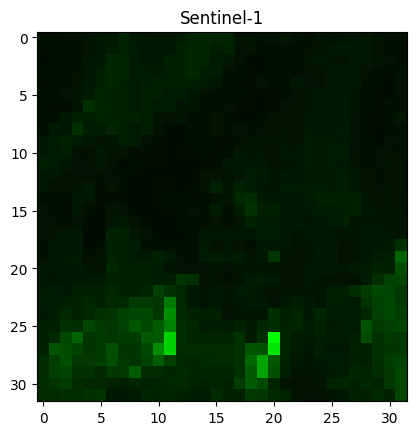

In [6]:
def false_color(X):
    VH = X[:,:,4]
    VV = X[:,:,5]
    
    c1 = 10e-4;
    c2 = 0.01;
    c3 = 0.02;
    c4 = 0.03;
    c5 = 0.045;
    c6 = 0.05;
    c7 = 0.9;
    c8 = 0.25;

    # Enhanced or non-enhanced option (set to "true" if you want enhanced)
    enhanced = True;

    if (enhanced): 
        band1 = c4 + np.log(c1 - np.log(c6 / (c3 + 2.5 * VV)) + np.log(c6 / (c3 + 1.5 * VH)))
        band2 = c6 + np.exp(c8 * (np.log(c2 + 2 * VV) + np.log(c3 + 7 * VH)))
        band3 = 0.8 - np.log(c6 / (c5 - c7 * VV))
    else:
        band1 = c4 + np.log(c1 - np.log(c6 / (c3 + 2 * VV)))
        band2 = c6 + np.exp(c8 * (np.log(c2 + 2 * VV) + np.log(c3 + 5 * VH)))
        band3 = 1 - np.log(c6 / (c5 - c7 * VV))

    band1 = band1 / (band1.max()/255.0)
    band2 = band2 / (band2.max()/255.0)
    band3 = band3 / (band3.max()/255.0)
        
    tc = np.dstack((band1, band2, band3))
    
    return tc.astype('uint8')

plt.imshow(false_color(sen1[class_sample[0],:,:,:]))
plt.title('Sentinel-1')

plt.show()

### Each image is a different sample (Different image, belonging to a different class)

/tmp/ipykernel_35799/172568809.py:18: RuntimeWarning: invalid value encountered in log
  band1 = c4 + np.log(c1 - np.log(c6 / (c3 + 2.5 * VV)) + np.log(c6 / (c3 + 1.5 * VH)))
/tmp/ipykernel_35799/172568809.py:20: RuntimeWarning: invalid value encountered in log
  band3 = 0.8 - np.log(c6 / (c5 - c7 * VV))
/tmp/ipykernel_35799/172568809.py:32: RuntimeWarning: invalid value encountered in cast
  return tc.astype('uint8')


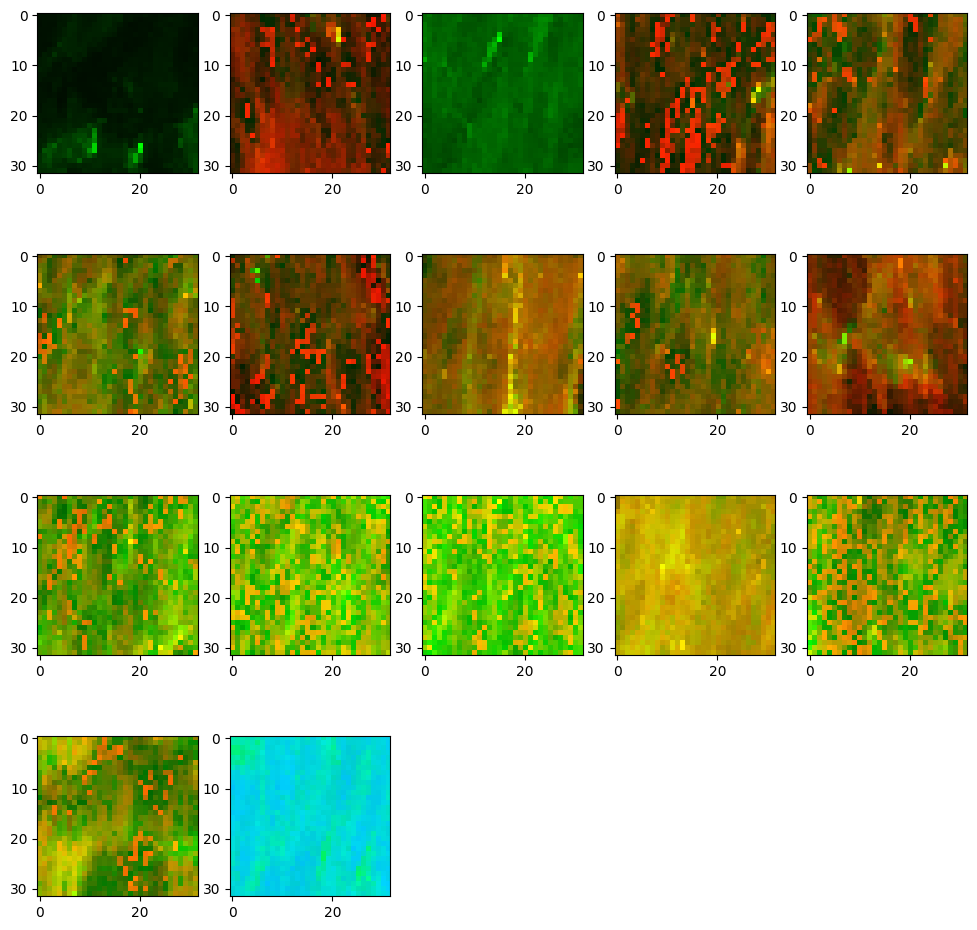

In [7]:
fig=plt.figure(figsize=(12, 12))

for i in range(17):
    fig.add_subplot(4, 5, i+1)
    plt.imshow(false_color(sen1[class_sample[i],:,:,:]))

plt.show()

### Do it yourself

Implement the radar vegetation indexing for visualization of Sentinel-1 data (for the [algorithm](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/radar_vegetation_index_code_dual_polarimetric/), please refer to Sentinel Hub), and check some results.

In [58]:
#This code was already done, the data scientists didin't know the physics behind it.
# The radar vegetation index (RVI) is a measure of the amount of vegetation present in a given area, based on the radar backscatter from the vegetation. It is calculated using the following formula
def calc_rvi(X):
    VH = X[:,:,4]
    VV = X[:,:,5]   
    
    dop = (VV / (VV + VH))
    m = 1 - dop # dop = degree of polarization
    radar_vegetation_index = (np.sqrt(dop))*((4*VH)/(VV+VH))
    radar_vegetation_index = ((4*VH)/(VV+VH))
    
    return radar_vegetation_index



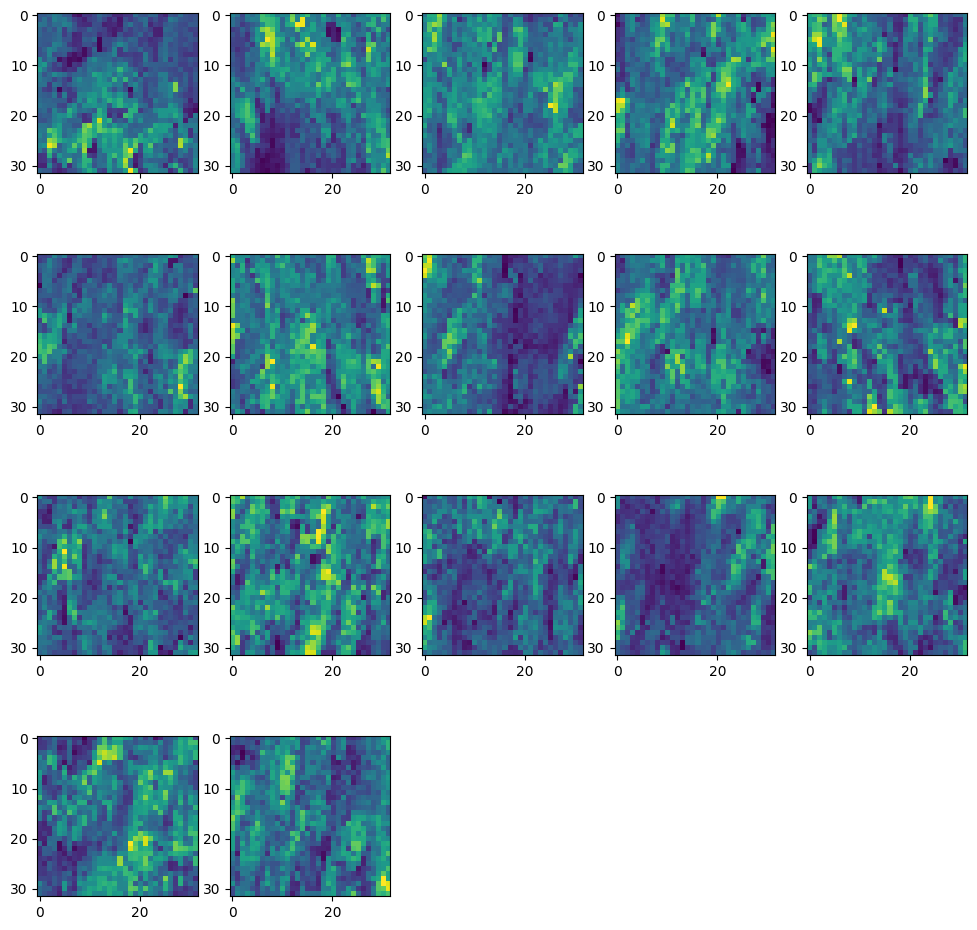

In [60]:
fig=plt.figure(figsize=(12, 12))

for i in range(17):
    fig.add_subplot(4, 5, i+1)
    plt.imshow(calc_rvi(sen1[class_sample[i],:,:,:]))

plt.show()

### Sentinel-2

Sentinel-2 Bands in So2Sat LCZ 42
1) Band B2 (Blue), 10m GSD  (1 pixel has 10m)
2) Band B3 (Green), 10m GSD
3) Band B4 (Red), 10m GSD
4) Band B5, upsampled to 10m from 20m GSD
5) Band B6, upsampled to 10m from 20m GSD
6) Band B7, upsampled to 10m from 20m GSD
7) Band B8, 10m GSD
8) Band B8a, upsampled to 10m from 20m GSD
9) Band B11, upsampled to 10m from 20m GSD
10) and Band B12, upsampled to 10m from 20m GSD

#### Some bands were discarted because for the particular problem it was not relevant.

### Every band is measuring an intensity Max 15000, nobody goes up from there,in the sensor it is discarded.... in the data there is a max value and that's the biggest valie you are getting.

Sentinel-2 shape: (2400, 32, 32, 10)


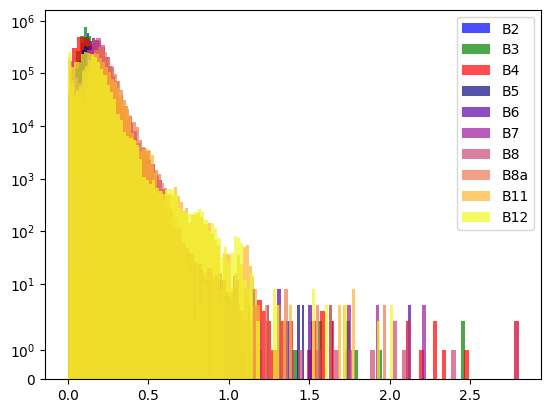

In [9]:
# load Sentinel-2 data
sen2 = np.array(dataset['sen2'])

print("Sentinel-2 shape: " + str(sen2.shape))

plt.hist(sen2[:,:,:,0].flatten(), color="blue", label="B2", alpha=0.7, bins=100)
plt.hist(sen2[:,:,:,1].flatten(), color="green", label="B3", alpha=0.7, bins=100)
plt.hist(sen2[:,:,:,2].flatten(), color="red", label="B4", alpha=0.7, bins=100)

cmap = colormaps['plasma']
plasma_colors = cmap(np.linspace(0, 1, 7))

band_labels = ["B5", "B6", "B7", "B8", "B8a", "B11", "B12"]

for band in range(3,10):
    plt.hist(sen2[:,:,:,band].flatten(), color=plasma_colors[band-3,], label=band_labels[band-3], alpha=0.7, bins=100)
plt.yscale('symlog')
plt.legend()
plt.show()

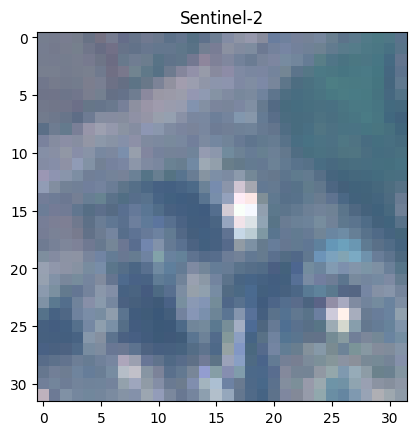

In [10]:
def true_color(X):
    """ Define True Color Sentinel image    
    The function returns the MinMax scaled RGB bands.
    Matplot convention RGB [0, 255]    
    """    
    blue = X[:,:,0] / (X[:,:,0].max()/255.0)
    green = X[:,:,1] / (X[:,:,1].max()/255.0)
    red = X[:,:,2] / (X[:,:,2].max()/255.0)
    
    tc = np.dstack((red, green, blue))     
    
    return tc.astype('uint8')

# show one patch
plt.imshow(true_color(sen2[class_sample[0],:,:,0:3]))
plt.title('Sentinel-2')

plt.show()


### Different clases, different kinds of landscapes

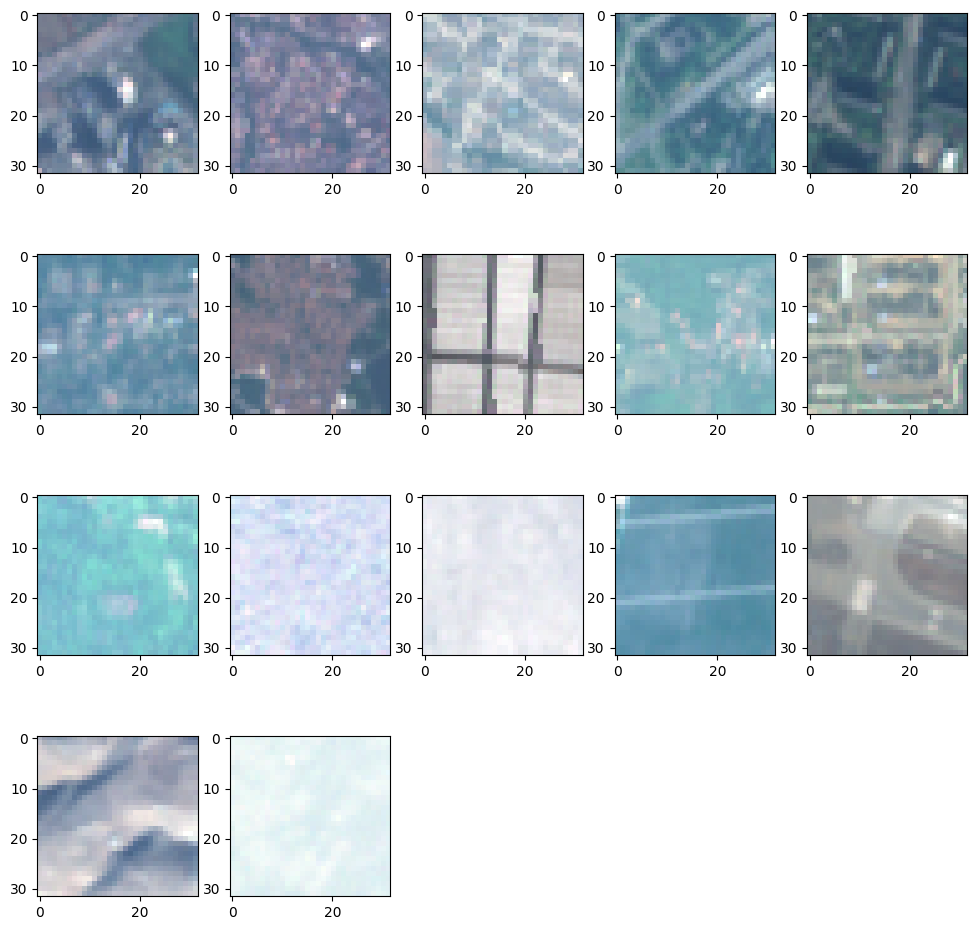

In [11]:
fig=plt.figure(figsize=(12, 12))

for i in range(17):
    fig.add_subplot(4, 5, i+1)
    plt.imshow(true_color(sen2[class_sample[i],:,:,:]))

plt.show()

### Do it yourself

The Normalized difference vegetation index (NDVI) is a simple, but effective index for quantifying green vegetation. It normalizes green leaf scattering in Near Infra-red wavelengths with chlorophyll absorption in red wavelengths.

It is defined as

$$ NDVI = Index(NIR, RED) = (NIR - RED) / (NIR + RED) $$

For Sentinel-2, NIR = B8 and RED = B4

Implement the NDVI and check some Sentinel-2 images.

In [56]:

def calc_ndvi(X):
    # RED is Band 4 (index 2), NIR is Band 8 (index 7)
    # Using [:, :, :, index] to handle (Batch, Height, Width, Bands)
    RED = X[:, :, :, 2].astype('float32')
    NIR = X[:, :, :, 7].astype('float32')
    
    # Calculate NDVI: (NIR - RED) / (NIR + RED)
    # We add 1e-10 to avoid dividing by zero if NIR + RED is 0
    ndvi = (NIR - RED) / (NIR + RED + 1e-10)
    ndvi = np.clip(ndvi, -1, 1)
    return ndvi


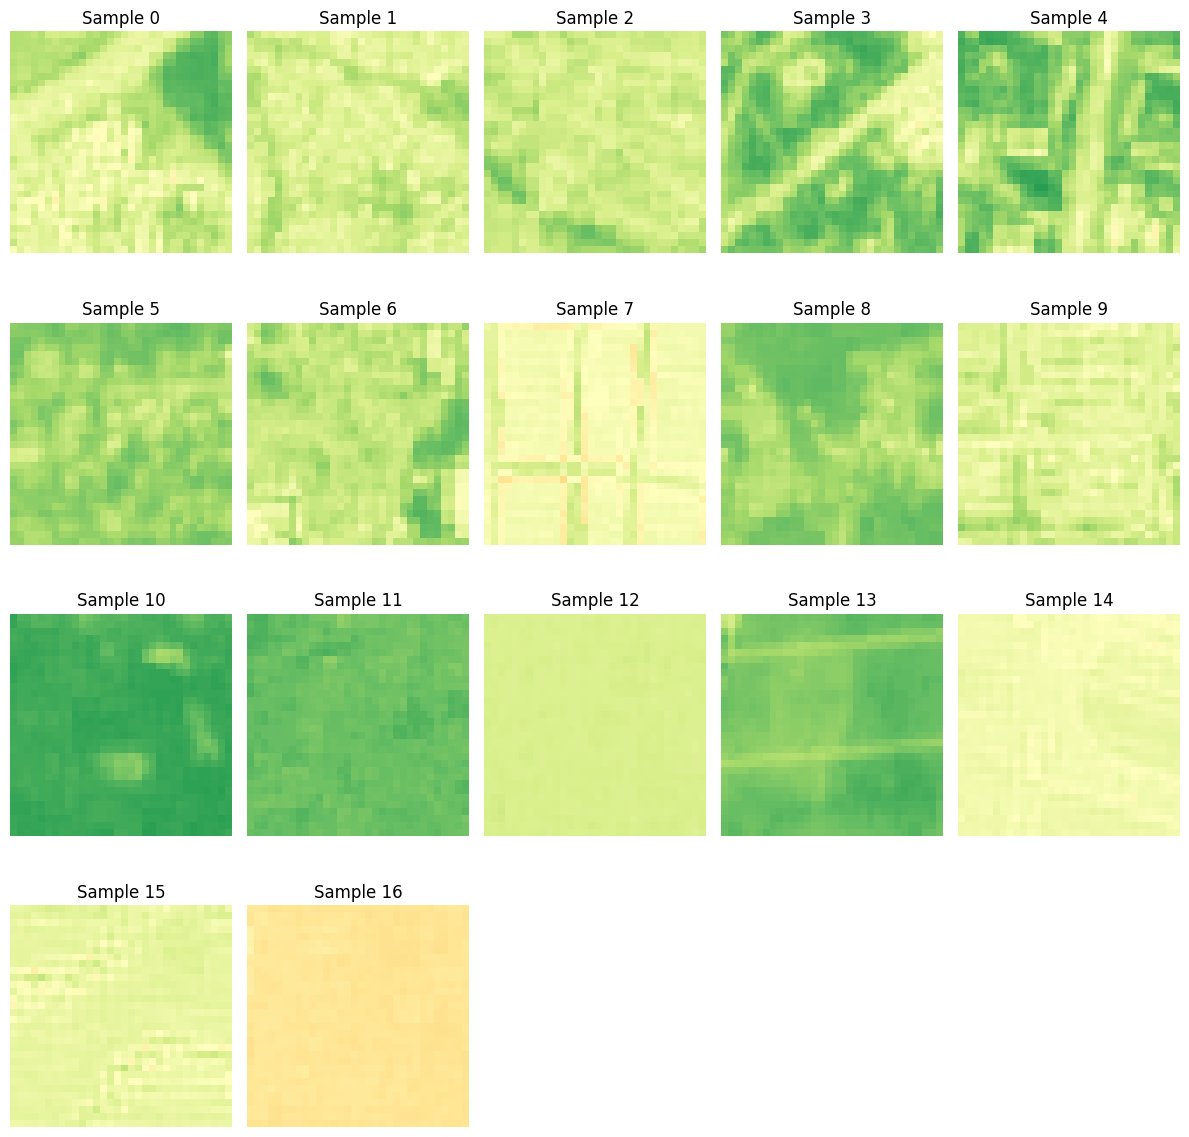

In [57]:
# 1. Calculate the NDVI for the entire dataset (or just the samples)
# This results in an array of shape (Samples, 32, 32)
ndvi_images = calc_ndvi(sen2)

fig = plt.figure(figsize=(12, 12))

for i in range(17):
    fig.add_subplot(4, 5, i+1)
    
    # 2. Get the NDVI map for the specific sample
    sample_ndvi = ndvi_images[class_sample[i]]
    
    # 3. Use a 'Green' colormap and set vmin/vmax
    # NDVI values always range from -1 to 1
    plt.imshow(sample_ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    plt.title(f"Sample {i}")
    plt.axis('off') # Optional: hides the pixel coordinates for a cleaner look

plt.tight_layout()
plt.show()

## 3. Machine Learning: Random Forest Classifier

Machine learning: A computer program is said to learn from experience E with respect to some task T and some performance measure P, if its performance on T, as measured by P, improves with experience E (*Tom M. Michell, 1997*).


A random forest is a meta estimator that fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

![Random Forest](random-forest.png)

In [13]:
# The random forest expects a vector of features. Therefore, Very specific formats.
# we concatenate all bands and pixels
number_samples = sen2.shape[0]
X = np.reshape(sen2, (number_samples, 32 * 32 * 10))

print("Post-processed Sentinel-2 data shape: ", X.shape)

# Let us split the data into train and test
TRAIN_SPLIT = int(number_samples * .8)

X_train = X[:TRAIN_SPLIT,:]
X_test = X[TRAIN_SPLIT:,:]



Post-processed Sentinel-2 data shape:  (2400, 10240)


In [15]:
# The labels are one hot encoded, but the random forest requires
# the class number -> We convert the one-hot encoded labels to class numbers using np.argmax
y_train = np.argmax(labels[0:TRAIN_SPLIT,:], axis=1)
y_test = np.argmax(labels[TRAIN_SPLIT:2400,:], axis=1)

print("Post-processed train labels shape: ", y_train.shape)

Post-processed train labels shape:  (1920,)


In [42]:
rf_classifier = RandomForestClassifier(random_state=0)

rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred_rf = rf_classifier.predict(X_test)

### Accuracy
#### Each number is the number of values classifies as such , for instance 7, there were 54 samples that were Class 7 and were classified as Class 7  , for instance class 16 (water) is very easy to classify, so it classified everything correctly.

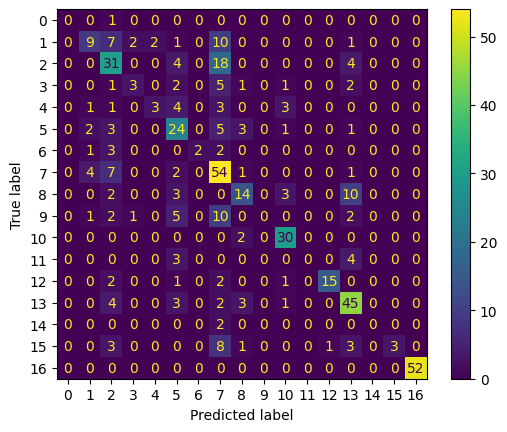

Accuracy Random Forest Classifier:  0.59375


In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest Classifier: ", acc_rf)

### Do it yourself

Train a random forest to predict the local climate zone using Sentinel-1 (or NDVI) images.

In [47]:
print(sen1.shape)
number_samples = sen1.shape[0]
Z = np.reshape(sen1, (number_samples, 32 * 32 * 8))

# Continue...to be done given time

(2400, 32, 32, 8)


In [49]:
print("Post-processed Sentinel-1 data shape: ", Z.shape)

Post-processed Sentinel-1 data shape:  (2400, 8192)


In [51]:
# Let us split the data into train and test
TRAIN_SPLIT = int(number_samples * .8)

X_train = Z[:TRAIN_SPLIT,:]
X_test = Z[TRAIN_SPLIT:,:]

In [52]:
# The labels are one hot encoded, but the random forest requires
# the class number -> We convert the one-hot encoded labels to class numbers using np.argmax
y_train = np.argmax(labels[0:TRAIN_SPLIT,:], axis=1)
y_test = np.argmax(labels[TRAIN_SPLIT:2400,:], axis=1)

print("Post-processed train labels shape: ", y_train.shape)

Post-processed train labels shape:  (1920,)


In [53]:
rf_classifier = RandomForestClassifier(random_state=0)

rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [54]:
y_pred_rf = rf_classifier.predict(X_test)

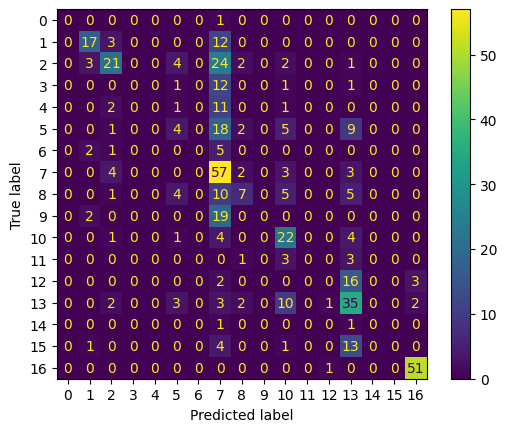

Accuracy Random Forest Classifier:  0.44583333333333336


In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest Classifier: ", acc_rf)

## 4. Other ML Models

There are multiple ML models for classification, including both supervised and unsupervised methods. For example, [here](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html) you can check several classifiers being compared.


#### Don't just run models just to run models.

In [19]:
svm_classifier = SVC()
svm_classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
y_pred_svm = svm_classifier.predict(X_test)

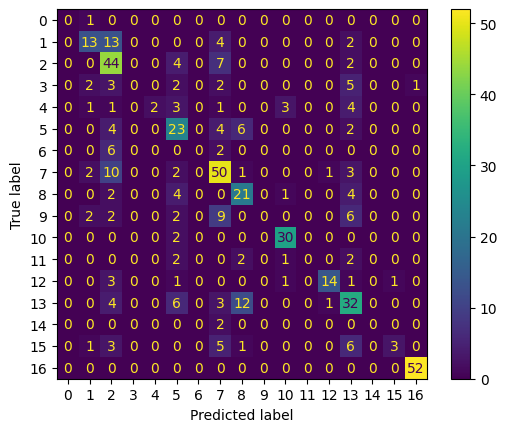

Accuracy SVM Classifier:  0.5916666666666667


In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.show()

acc_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy SVM Classifier: ", acc_svm)

##### This Accuracy is comparable in this case, but there should be a justification.
##### Start always with a very simple model, this will give you a sanity check... a value that is a good initial point as reference ... will cost 0 time, All well-performing models have been tested ... so use them .... THIS IS IMPORTANT BECAUSE NOONE KNOWS HOW DEEP LEARNING FULLY WORKS , SO THIS IS IMPORTANT.

### Do it yourself

Select another classifier, e.g., Nearest Neighbors, AdaBoost, Naive Bayes, etc., and compare the results.

In [44]:
from sklearn.naive_bayes import GaussianNB

nb_classifier = GaussianNB()

nb_classifier.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [45]:
y_pred_nb = nb_classifier.predict(X_test)

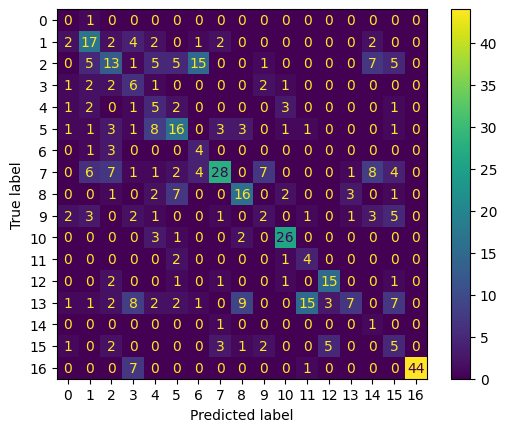

Accuracy Naive Bayes Classifier:  0.4354166666666667


In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.show()

acc_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy Naive Bayes Classifier: ", acc_nb)

## 5. Deep Learning

The human brain is a *machine* capable of performing very complex tasks, such as pattern recognition, motor control of a limb or perception of sensory stimuli, much faster than any machine invented by man. For this reason, great efforts have been (and continue to be) made to understand how they work. 

This machine is made up of about 100 trillion neurons (cells of the nervous system specialized in the reception and conduction of stimuli), which communicate with each other, forming complex circuits, which are capable of carrying out brain function. This biological model was the inspiration for McCulloch and Pitts to propose a [new computer model](https://www.cs.cmu.edu/~./epxing/Class/10715/reading/McCulloch.and.Pitts.pdf) in 1943: the *artificial neural network* (ANN).

An ANN is a network of computer units (neurons) connected to each other, where each unit performs a calculation from an input and communicates its result (output) to the connected units. Typically, the connections are weighted, which indicates how strong the connection between two units is. Also, the calculation units are usually grouped into modules or layers. ANNs have properties and capabilities that are very useful for solving complex problems, highlighting its nonlinearity, adaptability, fault tolerance, among others. Thanks to these properties, it has been possible to overcome the results obtained in multiple problems.

![Artificial neural network](ann.png)
    
Deep-learning methods are representation-learning methods with multiple levels of representation, obtained by composing simple but non-linear modules that each transform the representation at one level (starting with the raw input) into a representation at a higher, slightly more abstract level. With the composition of enough such transformations, very complex functions can be learned. *Yann LeCun, Yoshua Bengio and Geoffrey Hinton, 2015*

![Deep Learning](deep-learning.png)


In [22]:
Z_train = sen2[:TRAIN_SPLIT,:,:,:]
Z_test = sen2[TRAIN_SPLIT:,:,:,:]

print("Train shape: ", Z_train.shape, y_train.shape)

Train shape:  (1920, 32, 32, 10) (1920,)


In [ ]:
simple_model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 10)), # Flatten the input to a 1D vector
  tf.keras.layers.Dense(128, activation='relu'), # Fully connected layer with 128 neurons and ReLU activation
  tf.keras.layers.Dropout(0.2), # Dropout layer to prevent overfitting
  tf.keras.layers.Dense(17, activation='softmax') #17 classes, so 17 output neurons with softmax activation
])

simple_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/home/nathalia-uribe/DS_EO/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1778228290.834018   35799 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [24]:
simple_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,041 (5.01 MB)

 Trainable params: 1,313,041 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#y_train is already in class number format, so we can use it directly -> These are the labels for the training data, already converted to class numbers using np.argmax
history = simple_model.fit(Z_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2383 - loss: 2.5560 - val_accuracy: 0.3255 - val_loss: 2.2275
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3587 - loss: 2.1471 - val_accuracy: 0.3385 - val_loss: 2.0356
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3522 - loss: 2.0219 - val_accuracy: 0.4583 - val_loss: 1.9139
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3913 - loss: 1.9217 - val_accuracy: 0.4219 - val_loss: 1.8481
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4069 - loss: 1.8416 - val_accuracy: 0.4167 - val_loss: 1.7758


In [26]:
y_pred_dl_p = simple_model.predict(Z_test)

print("Prediction example: ", y_pred_dl_p[0,:], " Class: ", np.argmax(y_pred_dl_p[0,:]))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Prediction example:  [0.00801345 0.04379952 0.09018847 0.01742868 0.00571971 0.06941661
 0.03412377 0.4066435  0.01146744 0.03855802 0.00551578 0.01430176
 0.11048853 0.04338246 0.01181039 0.08651578 0.00262626]  Class:  7


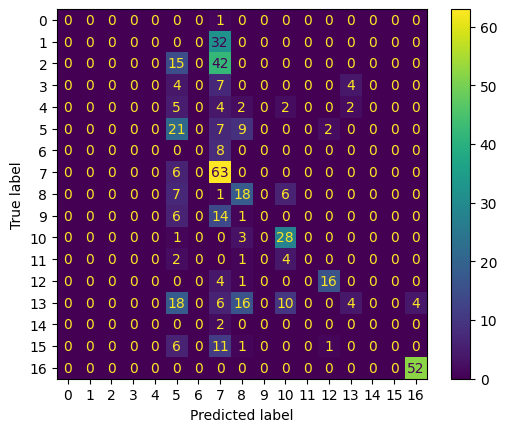

Accuracy Simple Deep Learning model:  0.42083333333333334


In [27]:
y_pred_dl = np.argmax(y_pred_dl_p, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl)
plt.show()

acc_dl = accuracy_score(y_test, y_pred_dl)
print("Accuracy Simple Deep Learning model: ", acc_dl)

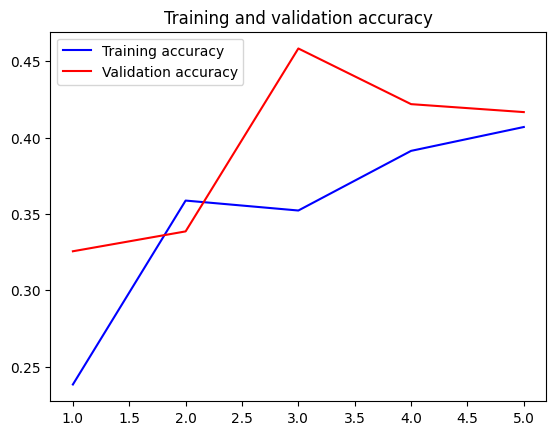

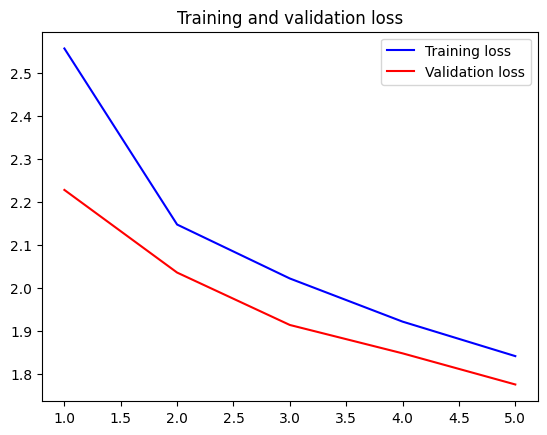

In [28]:
# print(history.history)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)


plt.figure()
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

### Do it yourself

Propose your own *simple* neural network model to predict the local climate zone.

/home/nathalia-uribe/DS_EO/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5


W0000 00:00:1778233107.111324   35799 cpu_allocator_impl.cc:82] Allocation of 78643200 exceeds 10% of free system memory.


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1948 - loss: 2.6969
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3141 - loss: 2.3100
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3443 - loss: 2.1442
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3469 - loss: 2.0566
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3500 - loss: 2.0014
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


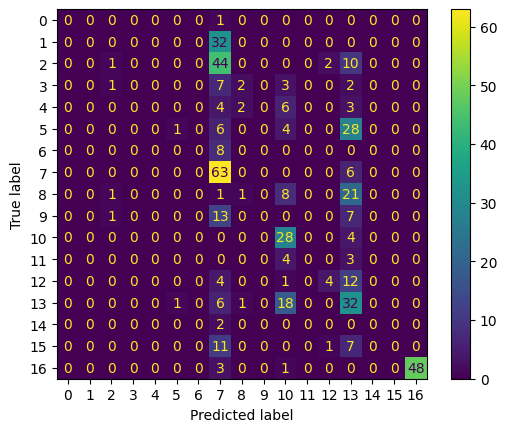

Accuracy Simple Deep Learning model DIY:  0.37083333333333335


In [34]:
# You may use the following code to get started...
simple_model_2 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 10)),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(17, activation='softmax')
])

simple_model_2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
simple_model_2.fit(Z_train, y_train, epochs=5)
y_pred_dl_p_2 = simple_model_2.predict(Z_test)

y_pred_dl_2 = np.argmax(y_pred_dl_p_2, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl_2)
plt.show()

acc_dl_2 = accuracy_score(y_test, y_pred_dl_2)
print("Accuracy Simple Deep Learning model DIY: ", acc_dl_2)

## 6. DL Preprocessing

DL models are sensitive to the hyperparameters and data dependent. Therefore, it is a good idea to spend some time preparing the data and tailoring the model.

In [ ]:
#The data is not normalized, so we can use a scaler to normalize the data before training the model. This is important for the performance of the model, especially for deep learning models.
#This process is called feature scaling, and it helps to ensure that all features contribute equally to the model's learning process. We can use StandardScaler from sklearn to standardize the features by removing the mean and scaling to unit variance.
s2_scaler = StandardScaler()
# the scaler expects data to have only two dimensions (i.e., a set of vectors)
s2_scaler.fit(X_train)

# we want to use the data without loosing spatial information
Z_train_scaled = s2_scaler.transform(X_train)
Z_train_scaled = Z_train_scaled.reshape(Z_train.shape)

# repeat for the test data
Z_test_scaled = s2_scaler.transform(X_test)
Z_test_scaled = Z_test_scaled.reshape(Z_test.shape)

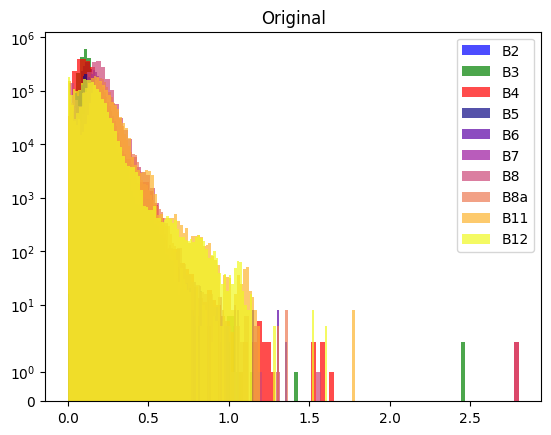

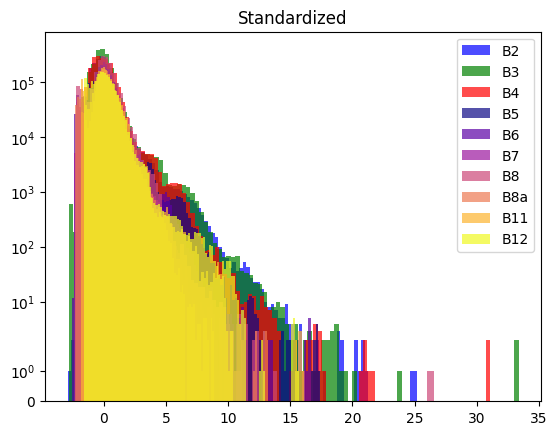

In [30]:
plt.figure()
plt.hist(Z_train[:,:,:,0].flatten(), color="blue", label="B2", alpha=0.7, bins=100)
plt.hist(Z_train[:,:,:,1].flatten(), color="green", label="B3", alpha=0.7, bins=100)
plt.hist(Z_train[:,:,:,2].flatten(), color="red", label="B4", alpha=0.7, bins=100)
for band in range(3,10):
    plt.hist(Z_train[:,:,:,band].flatten(), color=plasma_colors[band-3,], label=band_labels[band-3], alpha=0.7, bins=100)
plt.yscale('symlog')
plt.title("Original")
plt.legend()

plt.figure()
plt.hist(Z_train_scaled[:,:,:,0].flatten(), color="blue", label="B2", alpha=0.7, bins=100)
plt.hist(Z_train_scaled[:,:,:,1].flatten(), color="green", label="B3", alpha=0.7, bins=100)
plt.hist(Z_train_scaled[:,:,:,2].flatten(), color="red", label="B4", alpha=0.7, bins=100)
for band in range(3,10):
    plt.hist(Z_train_scaled[:,:,:,band].flatten(), color=plasma_colors[band-3,], label=band_labels[band-3], alpha=0.7, bins=100)
plt.yscale('symlog')
plt.title("Standardized")
plt.legend()
plt.show()

/home/nathalia-uribe/DS_EO/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3438 - loss: 5.8603 - val_accuracy: 0.3984 - val_loss: 3.9342
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4694 - loss: 3.7535 - val_accuracy: 0.4115 - val_loss: 3.8111
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4863 - loss: 3.7953 - val_accuracy: 0.4557 - val_loss: 4.0396
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5931 - loss: 2.5343 - val_accuracy: 0.4870 - val_loss: 3.3624
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5853 - loss: 2.8564 - val_accuracy: 0.4375 - val_loss: 5.0282
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


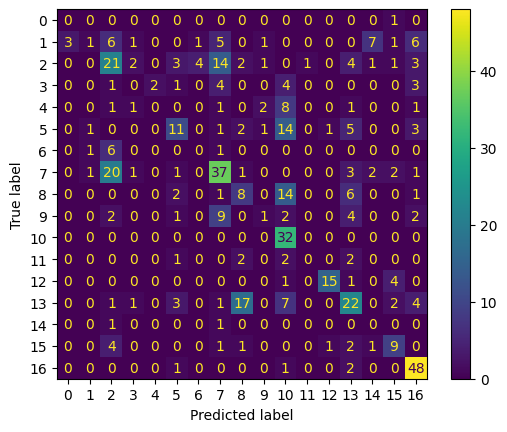

Accuracy Simple Deep Learning model with standardized data:  0.4270833333333333


In [31]:
simple_model_2 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 10)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(17, activation='softmax')
])

simple_model_2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_2 = simple_model_2.fit(Z_train_scaled, y_train, epochs=5, validation_split=0.2)

y_pred_dl_p_2 = simple_model_2.predict(Z_test_scaled)

y_pred_dl_2 = np.argmax(y_pred_dl_p_2, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl_2)
plt.show()

acc_dl_2 = accuracy_score(y_test, y_pred_dl_2)
print("Accuracy Simple Deep Learning model with standardized data: ", acc_dl_2)

**Why are we not improving?!?!**



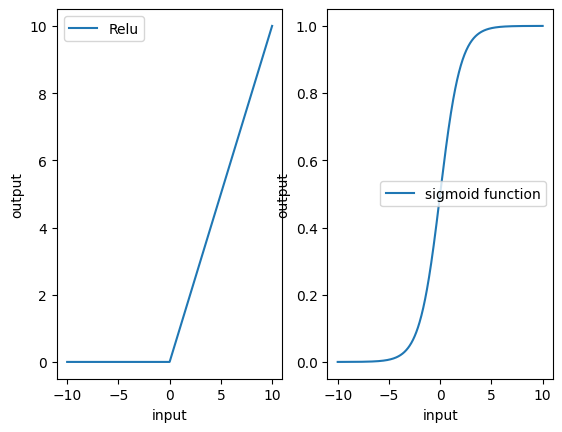

In [32]:
x = np.linspace(-10, 10, 1000)
y_sigmoid = 1 / (1 + np.exp(-x) )
y_relu = np.maximum(0, x)

plt.subplot(1,2,1)
plt.plot(x, y_relu)
plt.legend(['Relu'])
plt.xlabel('input')
plt.ylabel('output')

plt.subplot(1,2,2)
plt.plot(x, y_sigmoid)
plt.legend(['sigmoid function'])
plt.xlabel('input')
plt.ylabel('output')
plt.show()

In [ ]:
#The code is using the relu activation function, which is a common choice for hidden layers in deep learning models. The relu function is defined as f(x) = max(0, x), which means that it outputs the input directly if it is positive, and outputs zero if the input is negative. This helps to introduce non-linearity into the model, allowing it to learn more complex patterns in the data. The final layer uses the softmax activation function, which is appropriate for multi-class classification problems, as it converts the output into a probability distribution over the classes.
#Therefore with standarized data, roughly half of the data will be squished to zero, and the other half will be positive, which is ideal for the relu but for performance , i makes it stop learning, so we can use a different activation function, such as the sigmoid function, which outputs values between 0 and 1, or the leaky relu function, which allows a small gradient when the input is negative. This can help to improve the performance of the model when using standardized data.

/home/nathalia-uribe/DS_EO/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3991 - loss: 2.0362 - val_accuracy: 0.4349 - val_loss: 1.8430
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4915 - loss: 1.6451 - val_accuracy: 0.4271 - val_loss: 1.7517
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5117 - loss: 1.5186 - val_accuracy: 0.4193 - val_loss: 1.7069
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5579 - loss: 1.4289 - val_accuracy: 0.4609 - val_loss: 1.6386
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5957 - loss: 1.3464 - val_accuracy: 0.4818 - val_loss: 1.6106
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


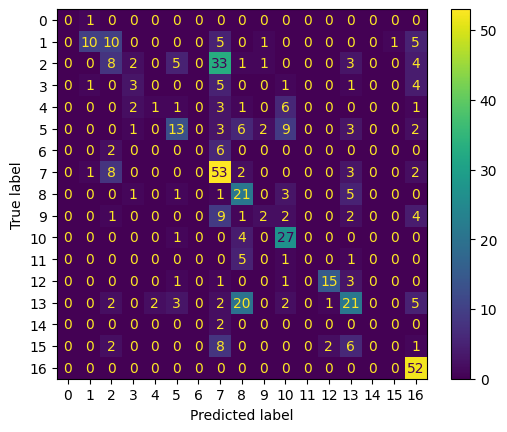

Accuracy Simple Deep Learning model with standardized data:  0.4708333333333333


In [ ]:
#Then we use a different activation function, such as the sigmoid function, which outputs values between 0 and 1, or the leaky relu function, which allows a small gradient when the input is negative. This can help to improve the performance of the model when using standardized data.
simple_model_3 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 10)),
  tf.keras.layers.Dense(128, activation='sigmoid'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(17, activation='softmax')
])

simple_model_3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_3 = simple_model_3.fit(Z_train_scaled, y_train, epochs=5, validation_split=0.2)

y_pred_dl_p_3 = simple_model_3.predict(Z_test_scaled)

y_pred_dl_3 = np.argmax(y_pred_dl_p_3, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl_3)
plt.show()

acc_dl_3 = accuracy_score(y_test, y_pred_dl_3)
print("Accuracy Simple Deep Learning model with standardized data: ", acc_dl_3)

## 7. Residual Networks

A residual neural network (ResNet) is an artificial neural network that imitate the pyramidal cells in the cerebral cortex. Particularly, the ResNet architecture consists of skip connections or shortcuts to jump over some layers. Typical ResNet models are implemented with double- or triple- layer skips that contain nonlinearities (ReLU) and batch normalization in between. These *cells* are known as *residual block*.

![Residual Block](residual-block.png)

ResNets connection weights are easier to optimize (especially for gradient descent-based optimizers) because the short cuts contribute to alleviate the vanishing gradient problem.

In practice, the degradation problem (i.e., increasing the depth of a network leads to a decrease in its performance) is mitigated, and the observed performance (when the number of hidden layers increase) is much closer to the theoretical one.

![Residual Network](residual-network.png)

Let us design a *deeper* model, based on ResNet... We will use Keras [implementation](https://github.com/keras-team/keras-applications/blob/master/keras_applications/resnet50.py) as our basis

In [61]:
def identity_block(
    input_tensor, 
    kernel_size, 
    filters, 
    stage,
    block):
    """The identity block is the block that has no conv layer at shortcut.
    # Arguments
        input_tensor: input tensor
        kernel_size: default 3, the kernel size of
            middle conv layer at main path
        filters: list of integers, the filters of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
    # Returns
        Output tensor for the block.
    """    
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # First component of main path
    x = tf.keras.layers.Conv2D(
        filters=F1, 
        kernel_size=(1, 1), 
        strides=(1,1), 
        padding='valid', 
        name=conv_name_base + '2a', 
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=0))(input_tensor)
    
    x = tf.keras.layers.BatchNormalization(
        axis=3, 
        name=bn_name_base + '2a')(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    # Second component of main path
    x = tf.keras.layers.Conv2D(
        filters=F2, 
        kernel_size=kernel_size, 
        strides=(1,1), 
        padding='same', 
        name=conv_name_base + '2b', 
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=0))(x)
    x = tf.keras.layers.BatchNormalization(
        axis=3, 
        name=bn_name_base + '2b')(x)
    x = tf.keras.layers.Activation('relu')(x)

    # Third component of main path
    x = tf.keras.layers.Conv2D(
        filters=F3, 
        kernel_size=(1, 1), 
        strides=(1,1), 
        padding='valid', 
        name=conv_name_base + '2c', 
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=0))(x)
    x = tf.keras.layers.BatchNormalization(axis = 3, name = bn_name_base + '2c')(x)

    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    x = tf.keras.layers.Add()([x, input_tensor])
    x = tf.keras.layers.Activation('relu')(x)  
    
    return x

In [62]:
def convolutional_block(
    input_tensor, 
    kernel_size, 
    filters, 
    stage, 
    block, 
    strides=(2, 2)):
    """A block that has a conv layer at shortcut.
    # Arguments
        input_tensor: input tensor
        kernel_size: default 3, the kernel size of
            middle conv layer at main path
        filters: list of integers, the filters of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
        strides: Strides for the first conv layer in the block.
    # Returns
        Output tensor for the block.
    """    
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    
    # Retrieve Filters
    F1, F2, F3 = filters

    # First component of main path 
    x = tf.keras.layers.Conv2D(
        F1, 
        (1, 1), 
        strides = strides, 
        name = conv_name_base + '2a', 
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=0))(input_tensor)
    
    x = tf.keras.layers.BatchNormalization(
        axis = 3, 
        name = bn_name_base + '2a')(x)
    
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(
        filters = F2, 
        kernel_size = kernel_size, 
        strides = (1,1), 
        padding = 'same', 
        name = conv_name_base + '2b', 
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=0))(x)
    
    x = tf.keras.layers.BatchNormalization(
        axis = 3, 
        name = bn_name_base + '2b')(x)
    
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(
        filters = F3, 
        kernel_size = (1, 1), 
        strides = (1,1), 
        padding = 'valid', 
        name = conv_name_base + '2c', 
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=0))(x)
    
    x = tf.keras.layers.BatchNormalization(axis = 3, name = bn_name_base + '2c')(x)

    tensor_shortcut = tf.keras.layers.Conv2D(
        filters = F3, 
        kernel_size = (1, 1), 
        strides = strides, 
        padding = 'valid', 
        name = conv_name_base + '1',
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=0))(input_tensor)
    tensor_shortcut = tf.keras.layers.BatchNormalization(
        axis = 3, 
        name = bn_name_base + '1')(tensor_shortcut)
    
    x = tf.keras.layers.Add()([x, tensor_shortcut])
    x = tf.keras.layers.Activation('relu')(x)
        
    return x

In [63]:
def ResNet50(input_shape=(32, 32, 10), classes=17):
    # Define the input of the model
    M_input = tf.keras.layers.Input(input_shape)
    print("Input shape", M_input.shape)

    # Add zero padding to the patch
    M = tf.keras.layers.ZeroPadding2D(padding=(3, 3))(M_input)
    
    # Stage 1
    M = tf.keras.layers.Conv2D(
        filters=64, 
        kernel_size=(7, 7), 
        strides=(2, 2), 
        name='conv1', 
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=0))(M)
    M = tf.keras.layers.BatchNormalization(
        axis=3, 
        name='bn_conv1')(M)
    M = tf.keras.layers.Activation('relu')(M)
    M = tf.keras.layers.MaxPool2D(
        pool_size=(3, 3), 
        strides=(2, 2))(M)
    print("Stage 1 shape", M.shape)

    # Stage 2
    M = convolutional_block(
        M, 
        kernel_size=3, 
        filters=[32, 32, 256], 
        stage=2, 
        block='a', 
        strides=(1, 1))
    M = identity_block(M, 3, [64, 64, 256], stage=2, block='b')
    M = identity_block(M, 3, [64, 64, 256], stage=2, block='c')
    print("Stage 2 shape", M.shape)

    # Stage 3
    M = convolutional_block(
        M, 
        kernel_size=3, 
        filters=[128, 128, 512], 
        stage = 3, 
        block='a', 
        strides=(1, 1))
    M = identity_block(M, 3, [128, 128, 512], stage=3, block='b')
    M = identity_block(M, 3, [128, 128, 512], stage=3, block='c')
    M = identity_block(M, 3, [128, 128, 512], stage=3, block='d')
    print("Stage 3 shape", M.shape)
    
    # Stage 4
    M = convolutional_block(
        M, 
        kernel_size=3, 
        filters=[256, 256, 1024], 
        stage = 4, 
        block='a', 
        strides=(2, 2))
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='b')
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='c')
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='d')
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='e')
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='f')
    print("Stage 4 shape", M.shape)

    # Stage 5
    M = convolutional_block(
        M, 
        kernel_size=3, 
        filters=[512, 512, 2048], 
        stage = 5, 
        block='a', 
        strides=(2, 2))
    M = identity_block(M, 3, [512, 512, 2048], stage=5, block='b')
    M = identity_block(M, 3, [512, 512, 2048], stage=5, block='c')
    print("Stage 5 shape", M.shape)

    # AVGPOOL
    M = tf.keras.layers.AveragePooling2D((2,2), name="avg_pool")(M)
    print("Avg pool shape", M.shape)
    
    # output layer
    M = tf.keras.layers.Flatten()(M)
    M = tf.keras.layers.Dense(
        classes, 
        activation='softmax', 
        name='fc' + str(classes), 
        kernel_initializer = tf.keras.initializers.GlorotUniform)(M)
    print("Output shape", M.shape)
    
    # Create model
    model = tf.keras.Model(inputs = M_input, outputs = M, name='ResNet50')
    return model

In [64]:
model_rn = ResNet50(input_shape=(32, 32, 10), classes=17)

model_rn.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

# Uncomment the following line to check the full model
model_rn.summary()

Input shape (None, 32, 32, 10)
Stage 1 shape (None, 7, 7, 64)
Stage 2 shape (None, 7, 7, 256)
Stage 3 shape (None, 7, 7, 512)
Stage 4 shape (None, 4, 4, 1024)
Stage 5 shape (None, 2, 2, 2048)
Avg pool shape (None, 1, 1, 2048)
Output shape (None, 17)


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 38, 38,    │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 16, 16,    │     31,424 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 16, 16,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 7, 7, 64)  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a      │ (None, 7, 7, 32)  │      2,080 │ max_pooling2d[0]… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2a       │ (None, 7, 7, 32)  │        128 │ res2a_branch2a[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 7, 7, 32)  │          0 │ bn2a_branch2a[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2b      │ (None, 7, 7, 32)  │      9,248 │ activation_1[0][… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2b       │ (None, 7, 7, 32)  │        128 │ res2a_branch2b[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 7, 7, 32)  │          0 │ bn2a_branch2b[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2c      │ (None, 7, 7, 256) │      8,448 │ activation_2[0][… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch1       │ (None, 7, 7, 256) │     16,640 │ max_pooling2d[0]… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2c       │ (None, 7, 7, 256) │      1,024 │ res2a_branch2c[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch1        │ (None, 7, 7, 256) │      1,024 │ res2a_branch1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 7, 7, 256) │          0 │ bn2a_branch2c[0]

 Total params: 23,606,289 (90.05 MB)

 Trainable params: 23,553,297 (89.85 MB)

 Non-trainable params: 52,992 (207.00 KB)

In [65]:
model_rn.fit(Z_train, y_train, epochs=5)

Epoch 1/5


W0000 00:00:1778236312.644868   35799 cpu_allocator_impl.cc:82] Allocation of 78643200 exceeds 10% of free system memory.


60/60 ━━━━━━━━━━━━━━━━━━━━ 75s 817ms/step - accuracy: 0.3568 - loss: 2.7666
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 828ms/step - accuracy: 0.4786 - loss: 1.8465
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 834ms/step - accuracy: 0.5240 - loss: 1.6932
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 46s 758ms/step - accuracy: 0.5500 - loss: 1.8205
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 43s 714ms/step - accuracy: 0.5677 - loss: 1.4258


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step


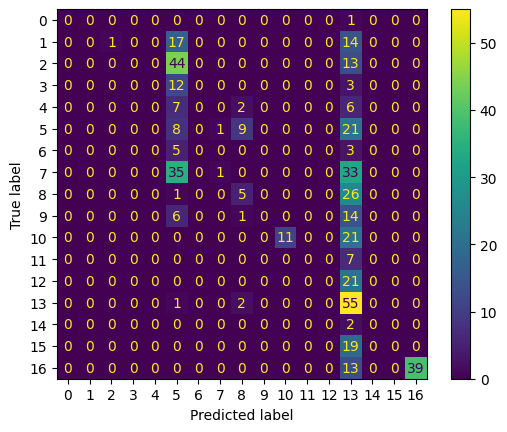

Accuracy ResNet-50 model:  0.24791666666666667


In [66]:
y_pred_rn_p = model_rn.predict(Z_test)

y_pred_rn = np.argmax(y_pred_rn_p, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rn)
plt.show()

acc_rn = accuracy_score(y_test, y_pred_rn)
print("Accuracy ResNet-50 model: ", acc_rn)

### Do it yourself

Play around with the ResNet50 model, e.g., by modifying the training process, and/or changing the training budget (number of epochs)

Input shape (None, 32, 32, 10)
Stage 1 shape (None, 7, 7, 64)
Stage 2 shape (None, 7, 7, 256)
Stage 3 shape (None, 7, 7, 512)
Stage 4 shape (None, 4, 4, 1024)
Stage 5 shape (None, 2, 2, 2048)
Avg pool shape (None, 1, 1, 2048)
Output shape (None, 17)
Epoch 1/5


W0000 00:00:1778236813.489122   35799 cpu_allocator_impl.cc:82] Allocation of 78643200 exceeds 10% of free system memory.


60/60 ━━━━━━━━━━━━━━━━━━━━ 74s 820ms/step - accuracy: 0.1875 - loss: 6.6163
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 826ms/step - accuracy: 0.3641 - loss: 2.3981
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 49s 821ms/step - accuracy: 0.3833 - loss: 2.2278
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 49s 812ms/step - accuracy: 0.4062 - loss: 1.8305
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 48s 794ms/step - accuracy: 0.4406 - loss: 1.7415
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step


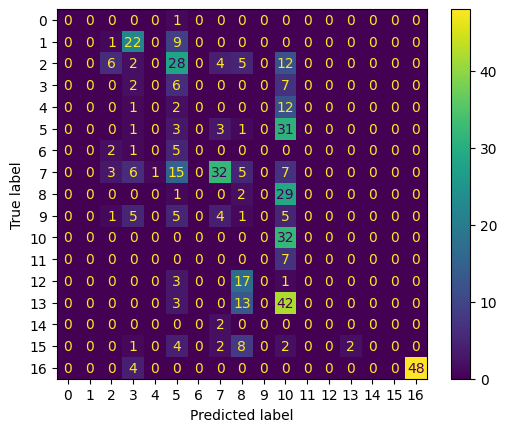

Accuracy ResNet-50 model:  0.2604166666666667


In [67]:
model_rn_diy = ResNet50(input_shape=(32, 32, 10), classes=17)

# let's define a schedule to lower the learning rate
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.9)

model_rn_diy.compile(
    # If you want to learn more about the Adam algorithm, 
    # visit https://www.tensorflow.org/versions/r2.6/api_docs/python/tf/keras/optimizers/Adam
    # or check Kingma et al. (2014) paper http://arxiv.org/abs/1412.6980
    optimizer=tf.keras.optimizers.Adam(        
        learning_rate=lr_schedule, # 0.001 is the standard value
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07,
        amsgrad=False), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

model_rn_diy.fit(Z_train, y_train, epochs=5)

y_pred_rn_p_diy = model_rn_diy.predict(Z_test)

y_pred_rn_diy = np.argmax(y_pred_rn_p_diy, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rn_diy)
plt.show()

acc_rn_diy = accuracy_score(y_test, y_pred_rn_diy)
print("Accuracy ResNet-50 model: ", acc_rn_diy)

How about using Sentinel-1 and -2 at the same time? Check the code, and try to improve the performance using what you have learnt

Original shape:  (2400, 32, 32, 8) (2400, 32, 32, 10)
Train shape:  (1920, 32, 32, 18) (1920,)
Test shape:  (480, 32, 32, 18) (480,)
Input shape (None, 32, 32, 18)
Stage 1 shape (None, 7, 7, 64)
Stage 2 shape (None, 7, 7, 256)
Stage 3 shape (None, 7, 7, 512)
Stage 4 shape (None, 4, 4, 1024)
Stage 5 shape (None, 2, 2, 2048)
Avg pool shape (None, 1, 1, 2048)
Output shape (None, 17)
Epoch 1/5


W0000 00:00:1778237097.658404   35799 cpu_allocator_impl.cc:82] Allocation of 141557760 exceeds 10% of free system memory.


60/60 ━━━━━━━━━━━━━━━━━━━━ 76s 854ms/step - accuracy: 0.2854 - loss: 3.7274
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 846ms/step - accuracy: 0.4260 - loss: 2.3382
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 49s 821ms/step - accuracy: 0.4615 - loss: 2.1636
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 44s 741ms/step - accuracy: 0.4839 - loss: 2.0251
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 45s 746ms/step - accuracy: 0.4922 - loss: 1.8369
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


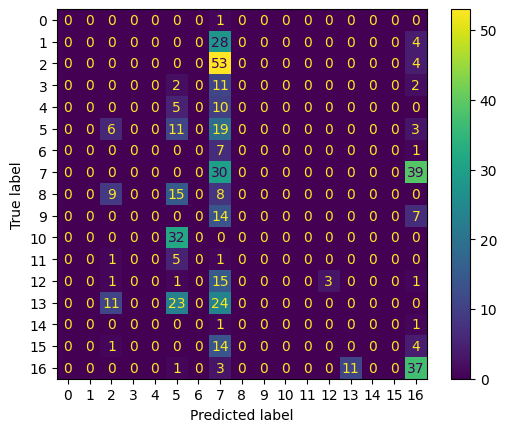

Accuracy ResNet-50 model using Sentinel-1 and 2:  0.16875


In [68]:
fusion_train = np.array(
    [np.dstack((s1, s2)) for s1, s2 in zip(sen1[:TRAIN_SPLIT,:,:,:], sen2[:TRAIN_SPLIT,:,:,:])])

fusion_test = np.array(
    [np.dstack((s1, s2)) for s1, s2 in zip(sen1[TRAIN_SPLIT:,:,:,:], sen2[TRAIN_SPLIT:,:,:,:])])

print("Original shape: ", sen1.shape, sen2.shape)
print("Train shape: ", fusion_train.shape, y_train.shape)
print("Test shape: ", fusion_test.shape, y_test.shape)

model_rn_fusion = ResNet50(input_shape=(32, 32, 18), classes=17)

model_rn_fusion.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

model_rn_fusion.fit(fusion_train, y_train, epochs=5)

y_pred_rn_fusion_p = model_rn_fusion.predict(fusion_test)

y_pred_rn_fusion = np.argmax(y_pred_rn_fusion_p, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rn_fusion)
plt.show()

acc_rn_fusion = accuracy_score(y_test, y_pred_rn_fusion)
print("Accuracy ResNet-50 model using Sentinel-1 and 2: ", acc_rn_fusion)

/home/nathalia-uribe/DS_EO/lib/python3.12/site-packages/keras/src/applications/densenet.py:206: UserWarning: This model usually expects 1 or 3 input channels. However, it was passed an input_shape with 10 input channels.
  input_shape = imagenet_utils.obtain_input_shape(


Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 48s 167ms/step - accuracy: 0.4297 - loss: 1.9763
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.5760 - loss: 1.4194
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.6146 - loss: 1.2446
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.6505 - loss: 1.0634
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.6807 - loss: 1.0008
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


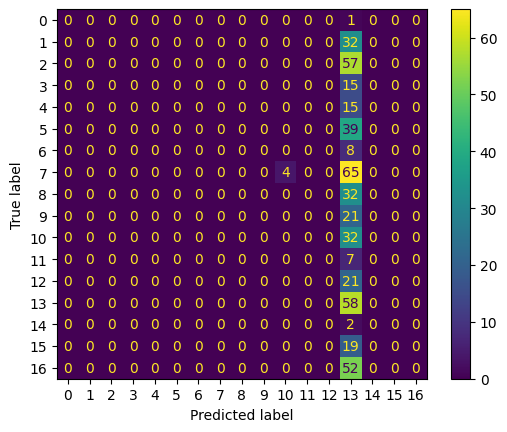

Accuracy DenseNet-121 model:  0.12083333333333333


In [71]:
# TODO: define your model!
import tensorflow as tf
from keras.applications import DenseNet121
import numpy as np

# 1. Define DenseNet121 
# It has more connections than ResNet but a similar 'time-cost' to train
model_dn_diy = DenseNet121(input_shape=(32, 32, 10), classes=17, weights=None)

# 2. Refined learning rate schedule
# We'll use a slightly more aggressive decay for the complex architecture
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=1000,
    decay_rate=0.9)

# 3. Compile with Adam
model_dn_diy.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

# 4. Training (The Budget)
# If accuracy is still low, consider increasing epochs to 10-15
model_dn_diy.fit(Z_train, y_train, epochs=5)

# 5. Prediction and Evaluation
y_pred_dn_p_diy = model_dn_diy.predict(Z_test)
y_pred_dn_diy = np.argmax(y_pred_dn_p_diy, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dn_diy)
plt.show()

acc_dn_diy = accuracy_score(y_test, y_pred_dn_diy)
print("Accuracy DenseNet-121 model: ", acc_dn_diy)

## References

1. He, K., Zhang, X., Ren, S. and Sun, J., 2016. Deep residual learning for image recognition. In Proceedings of the IEEE conference on computer vision and pattern recognition (CVPR) (pp. 770-778).
2. LeCun, Y., Bengio, Y. and Hinton, G., 2015. Deep learning. nature, 521(7553), pp.436-444.
3. McCarthy, J., 2007. What is artificial intelligence?
4. Mohri, M., Rostamizadeh, A. and Talwalkar, A., 2018. Foundations of machine learning. MIT press.
5. Zhu, X.X., Hu, J., Qiu, C., Shi, Y., Kang, J., Mou, L., Bagheri, H., Haberle, M., Hua, Y., Huang, R. and Hughes, L., 2020. So2Sat LCZ42: a benchmark data set for the classification of global local climate zones. IEEE Geoscience and Remote Sensing Magazine, 8(3), pp.76-89.
6. Zhu, X.X., Tuia, D., Mou, L., Xia, G.S., Zhang, L., Xu, F. and Fraundorfer, F., 2017. Deep learning in remote sensing: A comprehensive review and list of resources. IEEE Geoscience and Remote Sensing Magazine, 5(4), pp.8-36.